<a href="https://colab.research.google.com/github/incredible2003/-Sales-Dashboard-Power-BI-Project-/blob/main/Pand_num_Matplolib_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Data ready! Rows: 500
       Month  Units    Price   Revenue  Discount   Net_Rev
count  500.0  500.0    500.0     500.0     500.0     500.0
mean     6.0    5.0  30261.0  158033.0   12456.0  145577.0
std      3.0    3.0  24403.0  162117.0   17464.0  146024.0
min      1.0    1.0   4501.0    4504.0       0.0    4504.0
25%      3.0    3.0  14318.0   40418.0       0.0   36376.0
50%      6.0    5.0  24892.0  110424.0    4142.0  102648.0
75%      9.0    7.0  32100.0  210082.0   17642.0  191106.0
max     12.0    9.0  82336.0  733509.0   73350.0  660159.0


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/sales_dashboard.png'

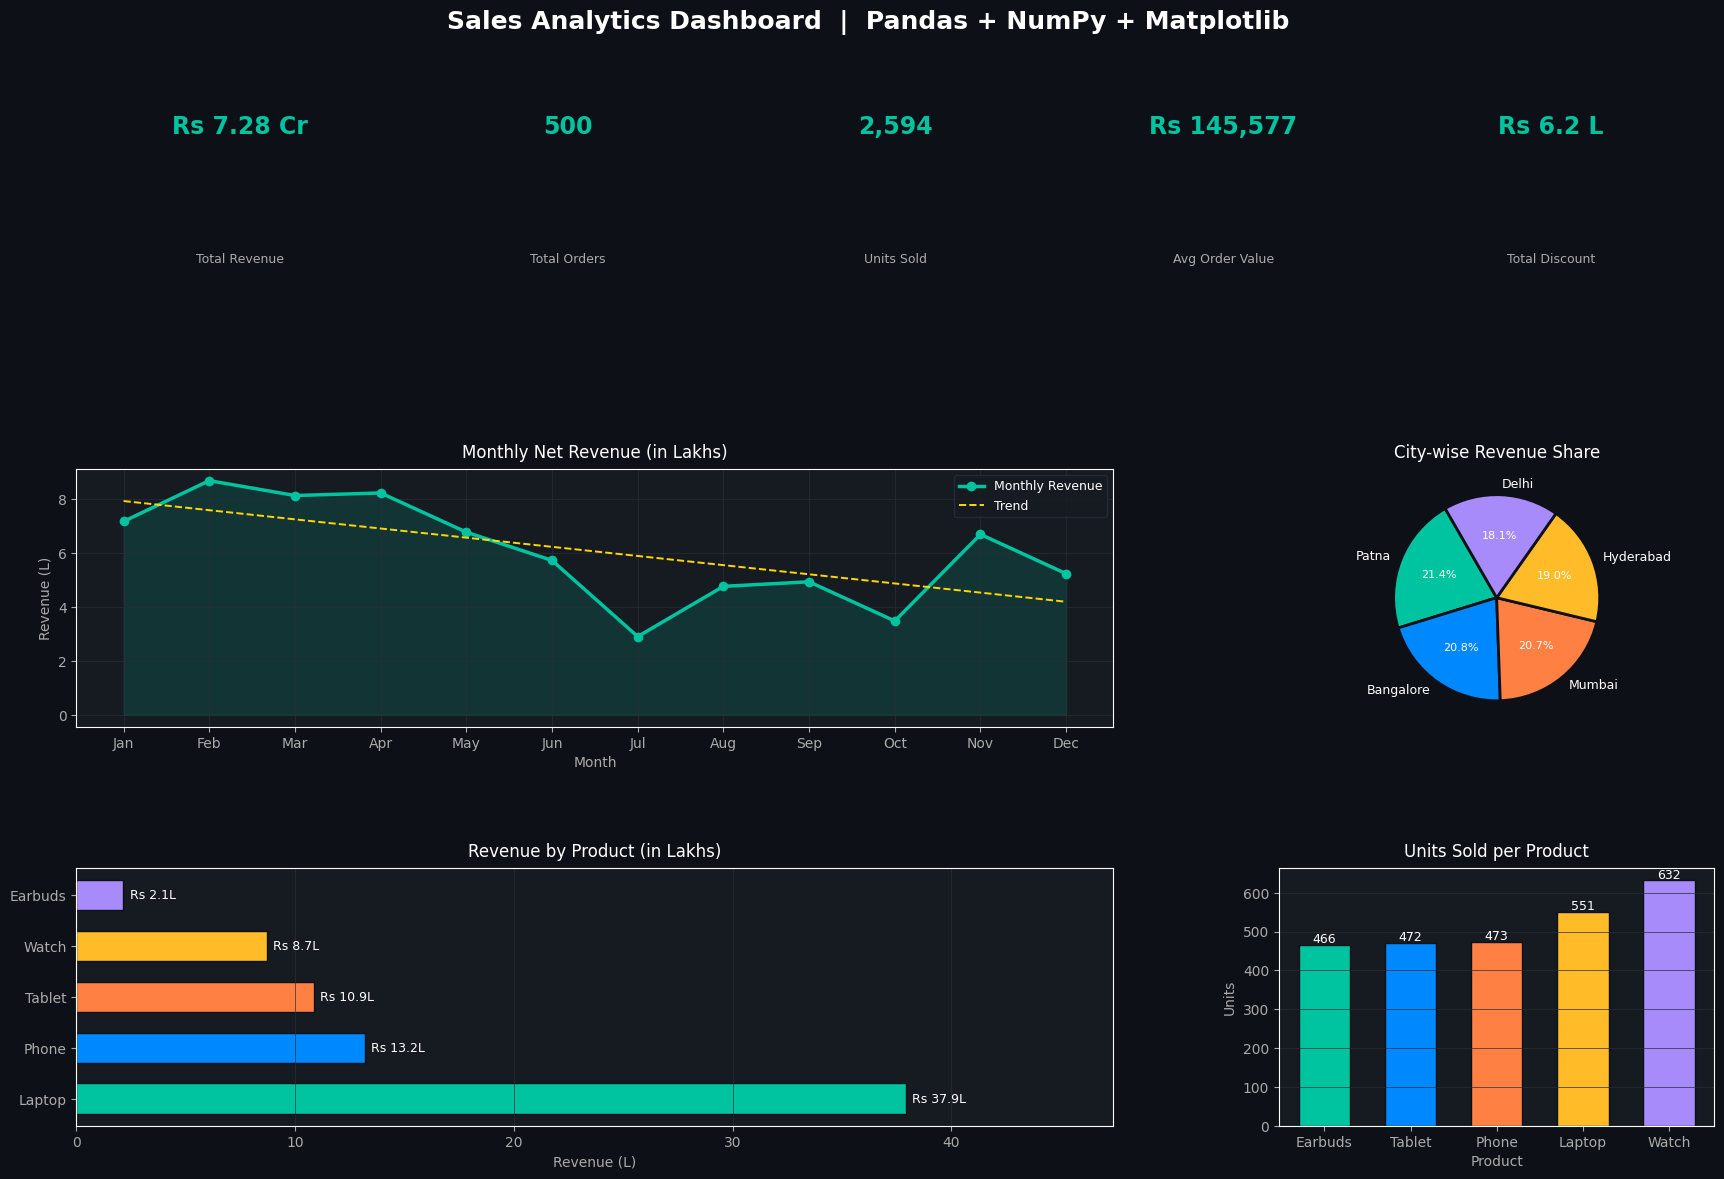

In [1]:
"""
================================================
  SALES ANALYTICS DASHBOARD
  Libraries: Pandas + NumPy + Matplotlib
================================================
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.ticker import FuncFormatter

# ══════════════════════════════════════════════
#  STEP 1 — NumPy se raw data banao
# ══════════════════════════════════════════════
np.random.seed(0)

N = 500   # 500 orders

products   = np.random.choice(["Laptop", "Phone", "Tablet", "Watch", "Earbuds"], N)
cities     = np.random.choice(["Delhi", "Mumbai", "Bangalore", "Patna", "Hyderabad"], N)
months     = np.random.choice(range(1, 13), N)
units_sold = np.random.randint(1, 10, N)

# Price alag alag product ke hisaab se
price_map = {"Laptop": 75000, "Phone": 30000, "Tablet": 25000,
             "Watch": 15000,  "Earbuds": 5000}
base_price = np.array([price_map[p] for p in products])
noise      = np.random.uniform(0.9, 1.1, N)   # +-10% price variation
price      = (base_price * noise).astype(int)

revenue    = units_sold * price
discount   = np.where(units_sold >= 5, revenue * 0.10, 0).astype(int)
net_rev    = revenue - discount

# ══════════════════════════════════════════════
#  STEP 2 — Pandas DataFrame banao + process karo
# ══════════════════════════════════════════════
df = pd.DataFrame({
    "Product":   products,
    "City":      cities,
    "Month":     months,
    "Units":     units_sold,
    "Price":     price,
    "Revenue":   revenue,
    "Discount":  discount,
    "Net_Rev":   net_rev,
})

# Month name add karo
month_names = {1:"Jan",2:"Feb",3:"Mar",4:"Apr",5:"May",6:"Jun",
               7:"Jul",8:"Aug",9:"Sep",10:"Oct",11:"Nov",12:"Dec"}
df["Month_Name"] = df["Month"].map(month_names)

# Aggregations (Pandas ka kaam)
monthly   = df.groupby("Month")["Net_Rev"].sum().sort_index()
prod_rev  = df.groupby("Product")["Net_Rev"].sum().sort_values(ascending=False)
city_rev  = df.groupby("City")["Net_Rev"].sum().sort_values(ascending=False)
prod_units= df.groupby("Product")["Units"].sum().sort_values()

print("Data ready! Rows:", len(df))
print(df.describe().round(0))

# ══════════════════════════════════════════════
#  STEP 3 — Matplotlib Dashboard
# ══════════════════════════════════════════════
plt.style.use("dark_background")
BG   = "#0D1117"
CARD = "#161B22"
GRID = "#2A2D3A"
COLORS = ["#00C49F","#0088FE","#FF8042","#FFBB28","#A78BFA"]

fig = plt.figure(figsize=(18, 12), facecolor=BG)
fig.suptitle("Sales Analytics Dashboard  |  Pandas + NumPy + Matplotlib",
             fontsize=18, fontweight="bold", color="white", y=0.99)

gs = gridspec.GridSpec(3, 3, figure=fig,
                       hspace=0.55, wspace=0.38,
                       left=0.06, right=0.97,
                       top=0.94, bottom=0.06)

# ── KPI boxes (top strip) ─────────────────────────────────
kpi_ax = fig.add_subplot(gs[0, :])
kpi_ax.set_facecolor(BG)
kpi_ax.axis("off")

kpis = [
    ("Total Revenue",   f"Rs {df['Net_Rev'].sum()/1e7:.2f} Cr"),
    ("Total Orders",    f"{len(df):,}"),
    ("Units Sold",      f"{df['Units'].sum():,}"),
    ("Avg Order Value", f"Rs {df['Net_Rev'].mean():,.0f}"),
    ("Total Discount",  f"Rs {df['Discount'].sum()/1e6:.1f} L"),
]

for i, (label, val) in enumerate(kpis):
    x = 0.10 + i * 0.20
    kpi_ax.text(x, 0.75, val, transform=kpi_ax.transAxes,
                fontsize=17, fontweight="bold", color="#00C49F", ha="center")
    kpi_ax.text(x, 0.25, label, transform=kpi_ax.transAxes,
                fontsize=9,  color="#AAAAAA", ha="center")

# ── Chart 1: Monthly Revenue (line) ──────────────────────
ax1 = fig.add_subplot(gs[1, :2])
ax1.set_facecolor(CARD)

m_labels = [month_names[m] for m in monthly.index]
ax1.plot(m_labels, monthly.values / 1e6, color="#00C49F",
         lw=2.5, marker="o", markersize=6, label="Monthly Revenue")
ax1.fill_between(m_labels, monthly.values / 1e6, alpha=0.15, color="#00C49F")

# Trend line (NumPy polyfit)
z   = np.polyfit(monthly.index, monthly.values / 1e6, 1)
p   = np.poly1d(z)
ax1.plot(m_labels, p(monthly.index), "--", color="#FFD700",
         lw=1.4, label="Trend")

ax1.set_title("Monthly Net Revenue (in Lakhs)", color="white", pad=8)
ax1.set_xlabel("Month", color="#AAAAAA")
ax1.set_ylabel("Revenue (L)", color="#AAAAAA")
ax1.tick_params(colors="#AAAAAA")
ax1.grid(color=GRID, linewidth=0.5)
ax1.legend(facecolor=CARD, edgecolor=GRID, labelcolor="white", fontsize=9)

# ── Chart 2: Product Revenue (horizontal bar) ─────────────
ax2 = fig.add_subplot(gs[2, :2])
ax2.set_facecolor(CARD)

bars = ax2.barh(prod_rev.index, prod_rev.values / 1e6,
                color=COLORS, edgecolor=BG, height=0.6)
# value labels
for bar, val in zip(bars, prod_rev.values):
    ax2.text(val / 1e6 + 0.3, bar.get_y() + bar.get_height() / 2,
             f"Rs {val/1e6:.1f}L", va="center", color="white", fontsize=9)

ax2.set_title("Revenue by Product (in Lakhs)", color="white", pad=8)
ax2.set_xlabel("Revenue (L)", color="#AAAAAA")
ax2.tick_params(colors="#AAAAAA")
ax2.grid(color=GRID, linewidth=0.5, axis="x")
ax2.set_xlim(0, prod_rev.max() / 1e6 * 1.25)

# ── Chart 3: City pie ─────────────────────────────────────
ax3 = fig.add_subplot(gs[1, 2])
ax3.set_facecolor(CARD)

wedges, texts, autos = ax3.pie(
    city_rev.values, labels=city_rev.index, colors=COLORS,
    autopct="%1.1f%%", startangle=120,
    wedgeprops=dict(edgecolor=BG, linewidth=2),
    textprops=dict(color="white", fontsize=9),
)
for at in autos: at.set_fontsize(8)
ax3.set_title("City-wise Revenue Share", color="white", pad=8)

# ── Chart 4: Units sold per product (bar) ────────────────
ax4 = fig.add_subplot(gs[2, 2])
ax4.set_facecolor(CARD)

ax4.bar(prod_units.index, prod_units.values,
        color=COLORS, edgecolor=BG, width=0.6)
for i, (prod, val) in enumerate(prod_units.items()):
    ax4.text(i, val + 5, str(val), ha="center", color="white", fontsize=9)

ax4.set_title("Units Sold per Product", color="white", pad=8)
ax4.set_xlabel("Product", color="#AAAAAA")
ax4.set_ylabel("Units", color="#AAAAAA")
ax4.tick_params(colors="#AAAAAA")
ax4.grid(color=GRID, linewidth=0.5, axis="y")

# ── Save ──────────────────────────────────────────────────
plt.savefig("/mnt/user-data/outputs/sales_dashboard.png",
            dpi=150, bbox_inches="tight", facecolor=BG)
print("\nDashboard save ho gaya!")


FileNotFoundError: [Errno 2] No such file or directory: '/mnt/user-data/outputs/p1_ipl_dashboard.png'

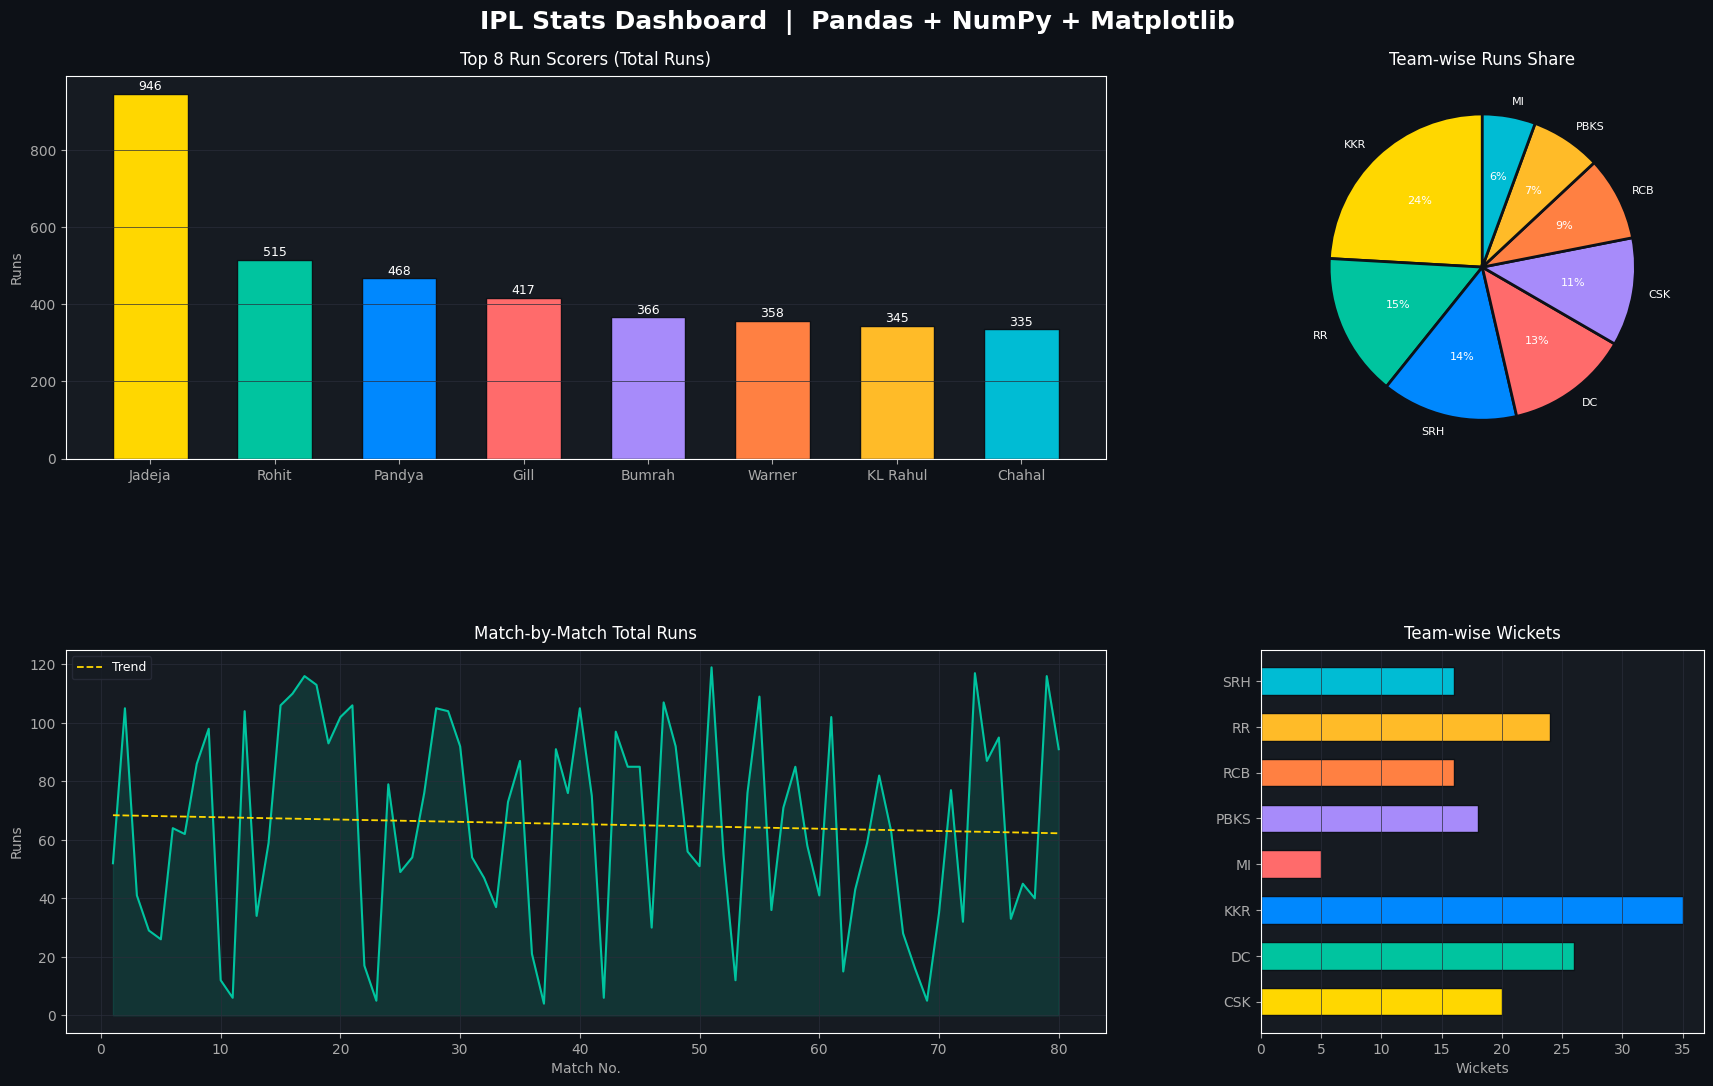

In [2]:
"""PROJECT 1: IPL Cricket Stats Dashboard"""
import numpy as np, pandas as pd, matplotlib.pyplot as plt, matplotlib.gridspec as gridspec

np.random.seed(7)
teams = ["MI","CSK","RCB","KKR","DC","SRH","PBKS","RR"]
players = ["Rohit","Kohli","Dhoni","KL Rahul","Warner","Buttler","Gill","Jadeja",
           "Bumrah","Shami","Chahal","Rashid","Pandya","DK","Gayle","Maxwell"]

N = 80
df = pd.DataFrame({
    "Player":  np.random.choice(players, N),
    "Team":    np.random.choice(teams, N),
    "Runs":    np.random.randint(0, 120, N),
    "Balls":   np.random.randint(10, 100, N),
    "Fours":   np.random.randint(0, 15, N),
    "Sixes":   np.random.randint(0, 10, N),
    "Wickets": np.random.randint(0, 5, N),
    "Match":   np.arange(1, N+1),
})
df["SR"] = (df["Runs"] / df["Balls"] * 100).round(1)

top_bat  = df.groupby("Player")["Runs"].sum().sort_values(ascending=False).head(8)
top_sr   = df.groupby("Player")["SR"].mean().sort_values(ascending=False).head(8)
team_runs= df.groupby("Team")["Runs"].sum().sort_values(ascending=False)
team_wkts= df.groupby("Team")["Wickets"].sum()
match_runs = df.groupby("Match")["Runs"].sum()

BG,CARD,GRID = "#0D1117","#161B22","#2A2D3A"
COLORS = ["#FFD700","#00C49F","#0088FE","#FF6B6B","#A78BFA","#FF8042","#FFBB28","#00BCD4"]

plt.style.use("dark_background")
fig = plt.figure(figsize=(18,11), facecolor=BG)
fig.suptitle("IPL Stats Dashboard  |  Pandas + NumPy + Matplotlib",
             fontsize=18, fontweight="bold", color="white", y=0.99)
gs = gridspec.GridSpec(2,3, figure=fig, hspace=0.50, wspace=0.35,
                       left=0.06, right=0.97, top=0.93, bottom=0.06)

# Chart 1: Top Run Scorers
ax1 = fig.add_subplot(gs[0,:2])
ax1.set_facecolor(CARD)
bars = ax1.bar(top_bat.index, top_bat.values, color=COLORS, edgecolor=BG, width=0.6)
for b in bars:
    ax1.text(b.get_x()+b.get_width()/2, b.get_height()+10,
             str(int(b.get_height())), ha="center", color="white", fontsize=9)
ax1.set_title("Top 8 Run Scorers (Total Runs)", color="white", pad=8)
ax1.set_ylabel("Runs", color="#AAAAAA"); ax1.tick_params(colors="#AAAAAA")
ax1.grid(color=GRID, linewidth=0.5, axis="y")

# Chart 2: Team Total Runs pie
ax2 = fig.add_subplot(gs[0,2])
ax2.set_facecolor(CARD)
ax2.pie(team_runs.values, labels=team_runs.index, colors=COLORS,
        autopct="%1.0f%%", startangle=90,
        wedgeprops=dict(edgecolor=BG, linewidth=2),
        textprops=dict(color="white", fontsize=8))
ax2.set_title("Team-wise Runs Share", color="white", pad=8)

# Chart 3: Match-by-match runs (line)
ax3 = fig.add_subplot(gs[1,:2])
ax3.set_facecolor(CARD)
ax3.plot(match_runs.index, match_runs.values, color="#00C49F", lw=1.5)
ax3.fill_between(match_runs.index, match_runs.values, alpha=0.15, color="#00C49F")
z = np.polyfit(match_runs.index, match_runs.values, 1)
ax3.plot(match_runs.index, np.poly1d(z)(match_runs.index),
         "--", color="#FFD700", lw=1.3, label="Trend")
ax3.set_title("Match-by-Match Total Runs", color="white", pad=8)
ax3.set_xlabel("Match No.", color="#AAAAAA"); ax3.set_ylabel("Runs", color="#AAAAAA")
ax3.tick_params(colors="#AAAAAA"); ax3.grid(color=GRID, linewidth=0.5)
ax3.legend(facecolor=CARD, edgecolor=GRID, labelcolor="white", fontsize=9)

# Chart 4: Team Wickets bar
ax4 = fig.add_subplot(gs[1,2])
ax4.set_facecolor(CARD)
ax4.barh(team_wkts.index, team_wkts.values, color=COLORS, edgecolor=BG, height=0.6)
ax4.set_title("Team-wise Wickets", color="white", pad=8)
ax4.set_xlabel("Wickets", color="#AAAAAA"); ax4.tick_params(colors="#AAAAAA")
ax4.grid(color=GRID, linewidth=0.5, axis="x")

plt.savefig("/mnt/user-data/outputs/p1_ipl_dashboard.png", dpi=150, bbox_inches="tight", facecolor=BG)
print("P1 done")
